# Доля золота в портфеле: 100% — миф, который стоил инвесторам 28 лет

*Авторская статья. Все расчёты и графики выполнены через библиотеку [okama](https://pypi.org/project/okama/). Сигнатуры и поведение используемых методов выверены по [официальной документации](https://okama.readthedocs.io/en/master/): `Asset.price`, `AssetList.wealth_indexes`, `get_cumulative_return(real=True)`, `get_cagr(real=True)`, `drawdowns`, `recovery_periods`, `assets_ror`.*

Цена золота в последние пару лет настолько быстро росла, что в каждом телеграм-канале появились свежеиспечённые "эксперты" по драгметаллам. Появился миф о том, что золото — это "актив на все случаи жизни".

Многие повелись на заголовки в СМИ и проповеди "аналитиков". Купили на самых высоких ценах. Потом, естественно, последовал откат — золото так умеет. Но в комментариях я до сих пор регулярно вижу искреннюю веру в то, что золото:

- всегда защищает от инфляции
- обеспечивает долгосрочный рост
- и вообще — можно вложить в него **100% портфеля** и спать спокойно

Давайте разберём эти мифы на исторических примерах.

## Подготовка окружения

Принцип работы с okama: использовать встроенные методы, а не считать вручную. Для конвертации валют — параметр `ccy` в `AssetList` (никакого умножения на курс). Для накопленной инфляции — `cumulative_inflation`. Для реальной доходности — `get_cumulative_return(real=True)`. Для просадок — `.drawdowns` и `.recovery_periods`. Для текущей цены — `Asset.price` (там, где работает).

In [1]:
# !pip install okama --quiet
import okama as ok
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print(f"okama version: {ok.__version__}")

okama version: 2.1.0


Прежде чем погружаться в историю, посмотрим на текущую цену золота на COMEX через `Asset.price` (live price, задержка ~15-20 минут):

In [2]:
gold = ok.Asset('GC.COMM')
print(f"{gold.name}")
print(f"Текущая цена: ${gold.price:,.2f} за тройскую унцию")
print(f"История данных: с {gold.first_date.date()} по {gold.last_date.date()}")

Gold (COMEX)


Текущая цена: $4,700.50 за тройскую унцию
История данных: с 1975-02-01 по 2026-05-01


## Глядя на историю, наступает отрезвление

У золота есть неприятная особенность, о которой современные "эксперты" предпочитают не вспоминать: оно умеет уходить в очень долгие просадки. Не на год и не на два — а на десятилетия.

### Просадка длиной в 28 лет (1980–2007)

В январе 1980 года цена золота достигла исторического пика. Те, кто купил золото на этом максимуме, ждали возврата к нему **почти 28 лет**.

Найдём это через встроенные методы `drawdowns` и `recovery_periods`:

In [3]:
al_long = ok.AssetList(['GC.COMM'], first_date='1975-01', last_date='2026-04', ccy='USD')

max_dd = al_long.drawdowns.min().iloc[0] * 100
recovery_months = al_long.recovery_periods.iloc[0]

print(f"Максимальная просадка золота за всю историю: {max_dd:.1f}%")
print(f"Длительность самой долгой просадки:          {recovery_months} мес ({recovery_months/12:.1f} лет)")
print()
print("Топ-5 самых глубоких точек просадки и когда они были:")
print((al_long.drawdowns.nsmallest(5, 'GC.COMM') * 100).round(1))

Максимальная просадка золота за всю историю: -63.4%
Длительность самой долгой просадки:          331 мес (27.6 лет)

Топ-5 самых глубоких точек просадки и когда они были:
Symbols  GC.COMM
date            
1999-08    -63.4
2001-03    -63.3
1999-07    -63.2
1999-06    -62.5
2001-04    -62.5


Самое дно — август 1999 года, просадка от пика 1980 года составила **−63,4%**. А теперь самое интересное: посмотрим на **реальную** доходность за период от пика 1980 до восстановления номинальной цены в сентябре 2007 года.

In [4]:
al_dd1980 = ok.AssetList(['GC.COMM'], first_date='1980-01', last_date='2007-09', ccy='USD')

nominal = al_dd1980.get_cumulative_return(real=False).iloc[-1]
real = al_dd1980.get_cumulative_return(real=True).iloc[-1].values[0]
cagr_real = al_dd1980.get_cagr(real=True).iloc[-1].values[0]

print(f"Период: {al_dd1980.first_date.date()} → {al_dd1980.last_date.date()} ({al_dd1980.period_length} лет)")
print(f"Номинальная доходность за период:     {nominal['GC.COMM']*100:+.1f}%")
print(f"Накопленная инфляция USD:              {nominal['USD.INFL']*100:+.1f}%")
print(f"Реальная доходность за период:        {real*100:+.1f}%")
print(f"Реальный CAGR:                         {cagr_real*100:+.2f}% годовых")

Период: 1980-01-01 → 2007-09-01 (27.68 лет)
Номинальная доходность за период:     +38.2%
Накопленная инфляция USD:              +171.8%
Реальная доходность за период:        -49.2%
Реальный CAGR:                         -2.41% годовых


**Итог:** инвестор, купивший золото на пике 1980 года, к моменту возврата номинальной цены через 27,7 лет потерял около **половины покупательной способности**. В годовом выражении — минус 2,4% в реальных долларах ежегодно. Это в среднем. По дороге было ещё хуже.

### Просадка после 2011 года

Второй пример свежее. Возьмём период с пика августа 2011 до восстановления:

In [5]:
al_dd2011 = ok.AssetList(['GC.COMM'], first_date='2011-08', last_date='2020-07', ccy='USD')

print(f"Период: {al_dd2011.first_date.date()} → {al_dd2011.last_date.date()} ({al_dd2011.period_length} лет)")
print(f"Максимальная просадка:                {al_dd2011.drawdowns.min().iloc[0]*100:.1f}%")
print(f"Длительность до восстановления:       {al_dd2011.recovery_periods.iloc[0]} мес")

Период: 2011-08-01 → 2020-07-01 (8.92 лет)
Максимальная просадка:                -42.0%
Длительность до восстановления:       106 мес


Девять лет в просадке — это, между прочим, дольше, чем большинство инвесторов вообще держат любой актив. И это в долларах, в более или менее стабильной валюте (хотя это тоже теперь факт, который можно подвергать сомнению).

Визуализируем всю историю золота с просадками:

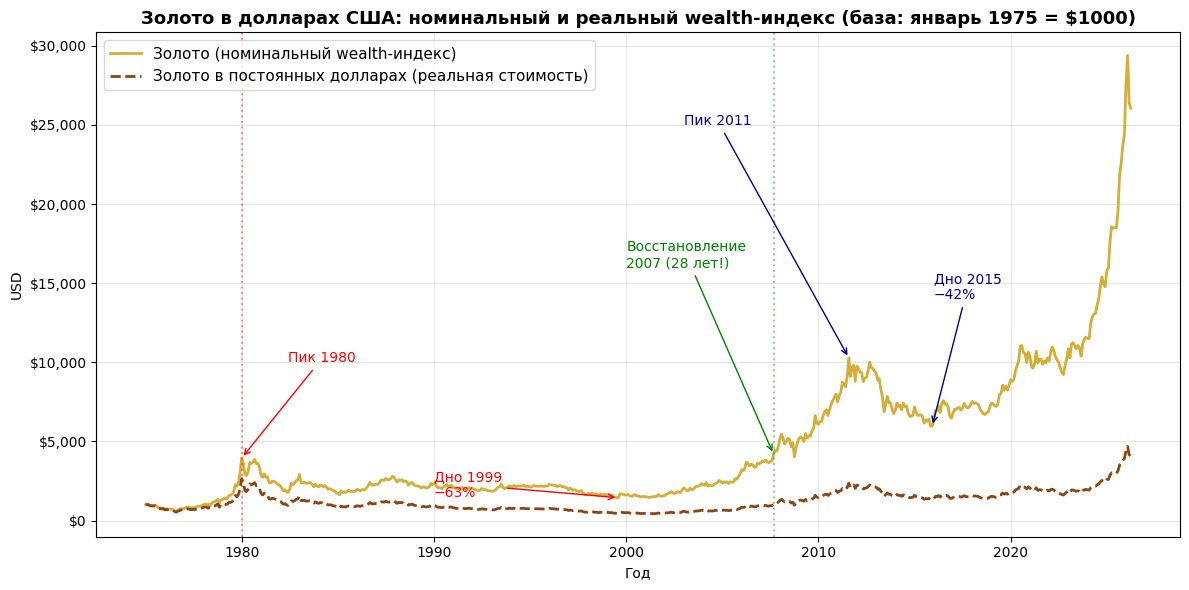

In [6]:
# Wealth index: рост 1000 USD во времени + строка инфляции для сравнения
wi = al_long.wealth_indexes
wi.index = wi.index.to_timestamp()

# Реальный wealth-индекс золота (в постоянных долларах)
real_wi = wi['GC.COMM'] / (wi['USD.INFL'] / wi['USD.INFL'].iloc[0])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wi.index, wi['GC.COMM'].values, color='#D4AF37', linewidth=2, label='Золото (номинальный wealth-индекс)')
ax.plot(real_wi.index, real_wi.values, color='#8B4513', linewidth=2, linestyle='--',
        label='Золото в постоянных долларах (реальная стоимость)')

ax.axvline(pd.Timestamp('1980-01-01'), color='red', alpha=0.4, linestyle=':')
ax.axvline(pd.Timestamp('2007-09-01'), color='green', alpha=0.4, linestyle=':')
ax.annotate('Пик 1980', xy=(pd.Timestamp('1980-01-01'), wi.loc['1980-01-01','GC.COMM']),
            xytext=(pd.Timestamp('1982-06-01'), 10000),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
ax.annotate('Восстановление\n2007 (28 лет!)', xy=(pd.Timestamp('2007-09-01'), wi.loc['2007-09-01','GC.COMM']),
            xytext=(pd.Timestamp('2000-01-01'), 16000),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')
ax.annotate('Дно 1999\n−63%', xy=(pd.Timestamp('1999-08-01'), wi.loc['1999-08-01','GC.COMM']),
            xytext=(pd.Timestamp('1990-01-01'), 1500),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=10, color='red')
ax.annotate('Пик 2011', xy=(pd.Timestamp('2011-08-01'), wi.loc['2011-08-01','GC.COMM']),
            xytext=(pd.Timestamp('2003-01-01'), 25000),
            arrowprops=dict(arrowstyle='->', color='darkblue'), fontsize=10, color='darkblue')
ax.annotate('Дно 2015\n−42%', xy=(pd.Timestamp('2015-12-01'), wi.loc['2015-12-01','GC.COMM']),
            xytext=(pd.Timestamp('2016-01-01'), 14000),
            arrowprops=dict(arrowstyle='->', color='darkblue'), fontsize=10, color='darkblue')

ax.set_title('Золото в долларах США: номинальный и реальный wealth-индекс (база: январь 1975 = $1000)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('USD')
ax.set_xlabel('Год')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

### А что в рублях? Защитило ли золото от российской инфляции?

Здесь начинается самое интересное. У нас же не доллары, у нас рубли. И у российского инвестора главный страх — это инфляция. Все ведь "знают", что золото — защита от инфляции. Так?

Конвертация в рубли — через параметр `ccy='RUB'` в AssetList. Он сам подтянет курсы, учтёт деноминацию 1998 года и подгрузит соответствующую инфляцию (`RUB.INFL`) для расчёта реальной доходности.

In [7]:
al_rub = ok.AssetList(['GC.COMM'], first_date='1992-08', last_date='2026-04', ccy='RUB')

nom = al_rub.get_cumulative_return(real=False).iloc[-1]
real_total = al_rub.get_cumulative_return(real=True).iloc[-1].values[0]
real_cagr = al_rub.get_cagr(real=True).iloc[-1].values[0]

print(f"Период: {al_rub.first_date.date()} → {al_rub.last_date.date()} ({al_rub.period_length} лет)")
print()
print(f"Цены в России выросли в                {nom['RUB.INFL']+1:,.0f} раз")
print(f"Цена золота в рублях выросла в         {nom['GC.COMM']+1:,.0f} раз")
print()
print(f"Реальная (за вычетом инфляции) доходность золота за 34 года: {real_total*100:+.1f}%")
print(f"Реальный CAGR:                                                {real_cagr*100:+.2f}% годовых")

Период: 1992-08-01 → 2026-04-01 (33.69 лет)

Цены в России выросли в                5,850 раз
Цена золота в рублях выросла в         5,957 раз

Реальная (за вычетом инфляции) доходность золота за 34 года: +1.8%
Реальный CAGR:                                                +0.05% годовых


С августа 1992 года по апрель 2026 года цены в России выросли почти в 5900 раз. Золото в рублях номинально обогнало инфляцию — но всего на **1,8% за 34 года**. В годовом выражении это **0,05% в реальном выражении**. Это статистический шум, не реальная доходность.

И это финальная точка. По пути было гораздо хуже — давайте посмотрим на просадки реальной стоимости золота в рублях:

In [8]:
# Реальный wealth-индекс золота в рублях (в постоянных рублях 1992-08)
wi_rub = al_rub.wealth_indexes
real_wi_rub = wi_rub['GC.COMM'] / (wi_rub['RUB.INFL'] / wi_rub['RUB.INFL'].iloc[0])

# Просадки реальной стоимости относительно исторического максимума
peak = real_wi_rub.expanding().max()
real_dd = (real_wi_rub / peak - 1) * 100

# Реальная стоимость относительно стартовой точки (1992-08 = 100)
rel_to_start = real_wi_rub / real_wi_rub.iloc[0] * 100

print(f"Максимальная просадка реальной стоимости золота: {real_dd.min():.1f}% (в {real_dd.idxmin()})")
print(f"Реальная стоимость сейчас (база 1992-08 = 100):   {rel_to_start.iloc[-1]:.0f}")
months_below = (real_wi_rub < real_wi_rub.iloc[0]).sum()
print(f"Из 404 месяцев в 1992–2026 реальная стоимость была ниже стартовой: {months_below} мес ({months_below/12:.1f} лет)")

Максимальная просадка реальной стоимости золота: -91.3% (в 1997-12)
Реальная стоимость сейчас (база 1992-08 = 100):   102
Из 404 месяцев в 1992–2026 реальная стоимость была ниже стартовой: 392 мес (32.7 лет)


Покупательная способность золота в рублях относительно августа 1992 года в декабре 1997 года рухнула до **9 от 100** — то есть инвестор за пять лет потерял 91% реальной стоимости. И из 34 лет реальная стоимость золота, купленного в 1992 году, **32,7 года была ниже стартовой**. Только в самые последние месяцы золото только-только перевалило обратно за исходный уровень.

Конечно, август 1992 года — это локальный пик: тогда цена золота в рублях временно "улетела" вверх из-за обвала рубля после либерализации. Но факт остаётся: золото не угналось за российской гиперинфляцией 1992–1995 годов, и тот, кто верил в "защиту от инфляции", получил очень болезненный урок.

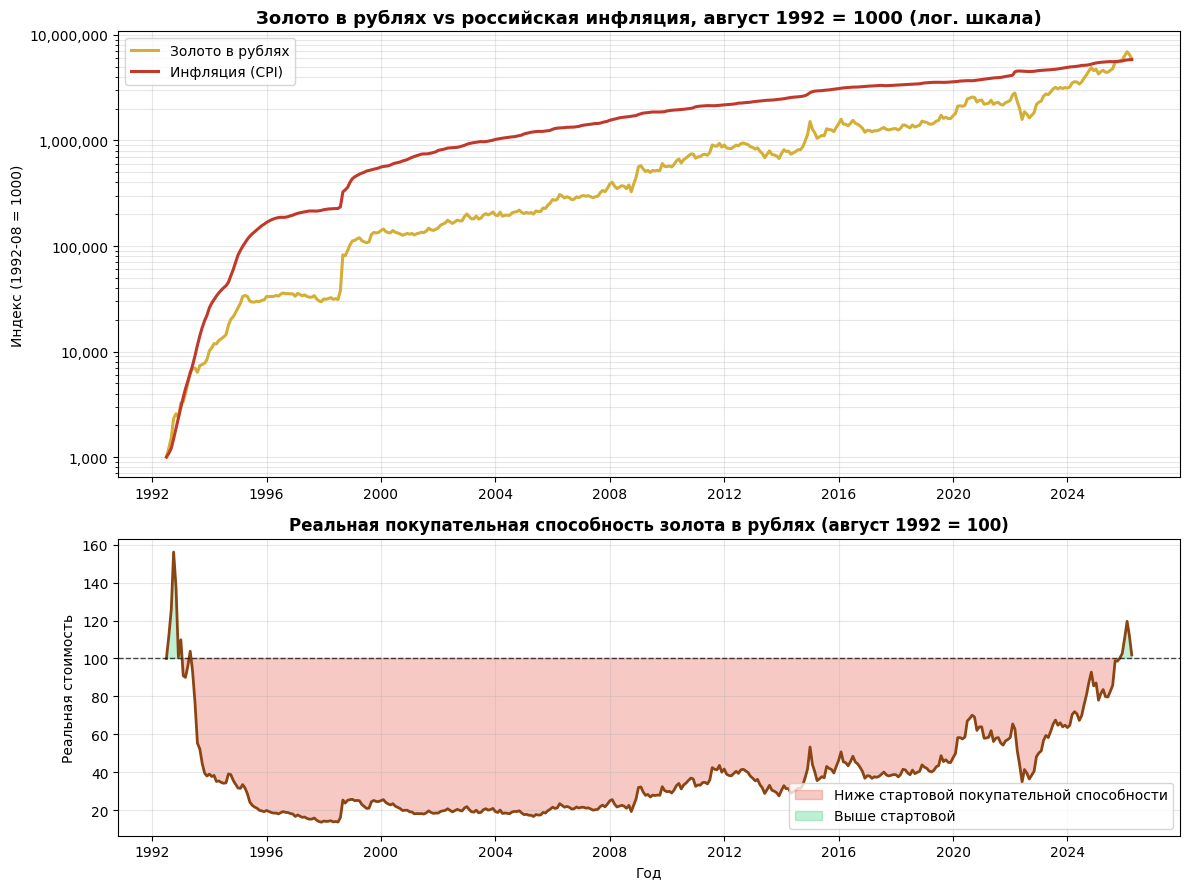

In [9]:
# График: золото в рублях vs CPI + панель реальной покупательной способности
wi_rub.index = wi_rub.index.to_timestamp()
real_wi_rub.index = real_wi_rub.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [3, 2]})

ax = axes[0]
ax.semilogy(wi_rub.index, wi_rub['GC.COMM'].values, color='#D4AF37', linewidth=2.2, label='Золото в рублях')
ax.semilogy(wi_rub.index, wi_rub['RUB.INFL'].values, color='#C0392B', linewidth=2.2, label='Инфляция (CPI)')
ax.set_title('Золото в рублях vs российская инфляция, август 1992 = 1000 (лог. шкала)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Индекс (1992-08 = 1000)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, which='both')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = axes[1]
rel = (real_wi_rub / real_wi_rub.iloc[0] * 100)
ax2.fill_between(rel.index, 100, rel.values,
                 where=(rel.values < 100), color='#E74C3C', alpha=0.3,
                 label='Ниже стартовой покупательной способности')
ax2.fill_between(rel.index, 100, rel.values,
                 where=(rel.values >= 100), color='#2ECC71', alpha=0.3,
                 label='Выше стартовой')
ax2.plot(rel.index, rel.values, color='#8B4513', linewidth=2)
ax2.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_title('Реальная покупательная способность золота в рублях (август 1992 = 100)',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Реальная стоимость')
ax2.set_xlabel('Год')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Миф о вечном росте золота легко разбивается о реальные данные. Просадки на 9, 28 и более лет — это нормально для этого актива. И даже "защита от инфляции" работает далеко не всегда.

## Так в чём же тогда сила золота?

Золото может уйти в долгую просадку, может не угнаться за инфляцией. Зачем тогда оно вообще нужно?

А нужно оно вот зачем: у золота есть одно очень полезное свойство — оно **слабо коррелирует с большинством других активов**. Иногда — особенно в кризисные моменты — золото буквально "вытягивает" портфель.

Посчитаем доходности активов в два знаменитых для нас кризисных эпизода через `AssetList`:

In [10]:
def crisis_returns(start, end, label):
    al = ok.AssetList(
        ['GLDRUB_TOM.COMM', 'MCFTR.INDX', 'RGBITR.INDX'],
        first_date=start, last_date=end, ccy='RUB', inflation=False
    )
    cr = al.get_cumulative_return().iloc[-1]
    print(f"{label:<32} Золото {cr['GLDRUB_TOM.COMM']*100:+6.1f}%   Акции {cr['MCFTR.INDX']*100:+6.1f}%   ОФЗ {cr['RGBITR.INDX']*100:+6.1f}%")

print("Доходности активов в рублях в кризисные эпизоды:\n")
crisis_returns('2014-08', '2014-12', '2014 (август–декабрь)')
crisis_returns('2020-01', '2020-04', 'Ковид (январь–апрель 2020)')

Доходности активов в рублях в кризисные эпизоды:



2014 (август–декабрь)            Золото  +45.7%   Акции   +2.7%   ОФЗ  -11.7%


Ковид (январь–апрель 2020)       Золото  +34.2%   Акции  -12.7%   ОФЗ   +3.7%


Во многих случаях золото буквально спасало портфель. Подробнее про этот эффект я уже писал в статье [Золото и акции](https://rostsber.ru/publish/stocks/gold_and_stocks.html).

А вот корреляционная матрица для российского инвестора — месячные доходности в рублях за последние 12 с лишним лет. Для расчёта используем `AssetList.assets_ror` — встроенные месячные returns:

In [11]:
al_corr = ok.AssetList(
    ['GLDRUB_TOM.COMM', 'MCFTR.INDX', 'RGBITR.INDX', 'RUS_SEC.RE', 'BTC-USD.CC'],
    first_date='2013-11', ccy='RUB', inflation=False
)

returns = al_corr.assets_ror
corr = returns.corr()

# Человекочитаемые имена для графика
labels_ru = ['Золото', 'Акции\n(MOEX)', 'Облигации\n(RGBITR)',
             'Недвижимость\n(вторичка РФ)', 'Биткойн\n(в рублях)']
corr_display = corr.copy()
corr_display.index = labels_ru
corr_display.columns = labels_ru

print(f"Период: {al_corr.first_date.date()} → {al_corr.last_date.date()} ({len(returns)} мес.)\n")
print("Корреляции золота:")
for asset, value in corr.iloc[0].items():
    if asset != 'GLDRUB_TOM.COMM':
        print(f"  {asset:<25} {value:+.2f}")

Период: 2013-11-01 → 2026-05-01 (151 мес.)

Корреляции золота:
  MCFTR.INDX                -0.13
  RGBITR.INDX               -0.51
  RUS_SEC.RE                +0.06
  BTC-USD.CC                +0.03


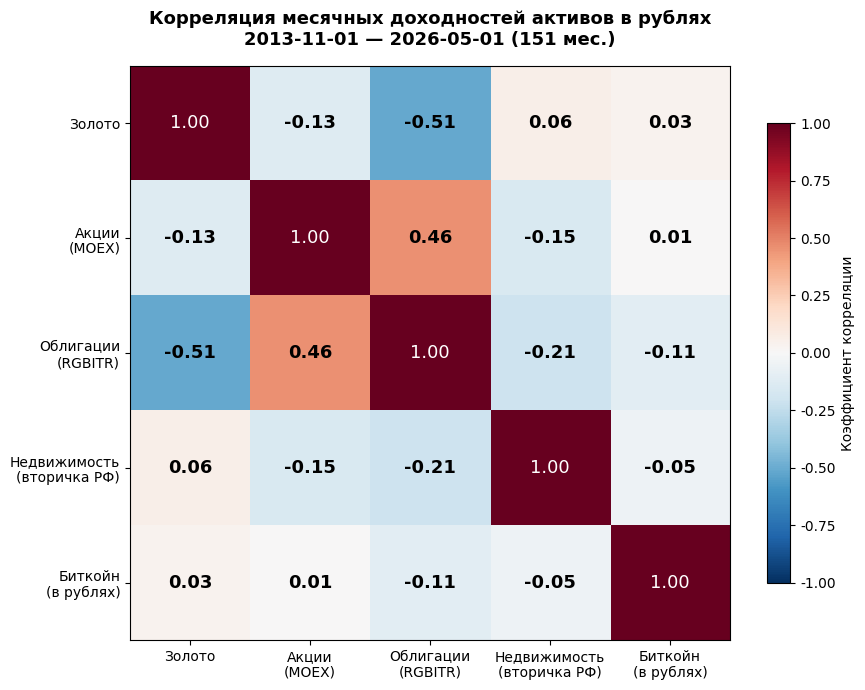

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_display.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_display.columns)))
ax.set_yticks(range(len(corr_display.index)))
ax.set_xticklabels(corr_display.columns, fontsize=10)
ax.set_yticklabels(corr_display.index, fontsize=10)

for i in range(len(corr_display.index)):
    for j in range(len(corr_display.columns)):
        v = corr_display.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.6 else 'black',
                fontsize=13, fontweight='bold' if i != j else 'normal')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Коэффициент корреляции')
ax.set_title(f'Корреляция месячных доходностей активов в рублях\n'
             f'{al_corr.first_date.date()} — {al_corr.last_date.date()} ({len(returns)} мес.)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Что мы тут видим:**

- Золото и акции: слабая отрицательная корреляция
- Золото и облигации: заметная отрицательная корреляция (когда золото растёт, ОФЗ часто падают, и наоборот)
- Золото и недвижимость: практически не коррелируют
- Золото и биткойн: слабая положительная корреляция

Перевожу с математического на человеческий: золото движется **отдельно** от других активов. Это и есть его суперсила. Не "высокая доходность" и не "защита от инфляции" (см. предыдущий раздел), а именно низкая корреляция. Добавление золота в диверсифицированный портфель снижает общую волатильность и просадки — но только в составе портфеля.

## Почему предсказать цену золота — невозможно

Ещё один важный момент, который любят забывать золотые евангелисты. Цена золота — это не цена акции и не цена облигации. У неё нет ни денежного потока, ни внутренней стоимости, ни справедливой цены, рассчитываемой по DCF-модели.

Промышленное использование золота — это всего **около 5%** мирового спроса. Остальные 95% — это инвестиционный и ювелирный спрос, плюс закупки центробанков. То есть цена золота на 95% определяется **настроениями, эмоциями и геополитикой**.

А это значит, что:

- краткосрочную цену предсказать невозможно (а кто говорит обратное — продаёт вам что-то)
- долгосрочную цену тоже предсказать трудно — у золота нет "справедливой стоимости", к которой оно должно вернуться. Ориентир тут инфляция… но вы видели, что и это не всегда работает
- текущий рост может продолжаться ещё годы, а может развернуться в любой момент

Когда кто-то уверенно говорит вам, что "золото обязательно вырастет до $5000 (или $10000, или сколько там сейчас популярно в инсайдерских каналах)" — это не аналитика, это гадание. Иногда верное, иногда нет. Стройте свой портфель так, чтобы быть готовым к любым вариантам.

## Выводы

- **Золото слишком рискованно покупать как единственный актив.** Никакие "уникальные свойства" не спасут от 28-летней просадки. Если вам не повезло с точкой входа — у вас есть все шансы прожить остаток инвестиционного горизонта в минусе

- **Золото отлично работает в составе диверсифицированного портфеля.** Вместе с акциями, облигациями и недвижимостью — благодаря низкой корреляции оно снижает общий риск и помогает пережить кризисы

- **В российских портфелях доля золота закономерно выше, чем в "учебниковых" глобальных портфелях.** У российского инвестора сейчас нет надёжных способов покупать иностранные акции и облигации. Нет нормальных инструментов для инвестиций в недвижимость через ценные бумаги. Поэтому золото частично закрывает эти дыры в диверсификации. Это нормально. Чем агрессивнее портфель, тем больше в нём может быть золота

- **Хороший вариант диверсификации для российского инвестора — новый БПИФ Портфель лежебоки (SPRN).** Внутри уже сбалансированный набор активов, включая золото в разумной пропорции — не как единственный, а как один из. [Наш подробный обзор SPRN](https://rostsber.ru/publish/stocks/sprn.html)